# ML Studio – Session 1  
# Understanding Models Visually

Iman Mossavat

---

A classifier is a function that **divides the input space**.

Different algorithms divide the input space differently.

Today:
- We do not focus on accuracy.
- We focus on **geometry**.
- We compare how models divide the space by *drawing decision boundaries*.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

plt.rcParams["figure.figsize"] = (6, 5)


This is a helper function used to draw 2 dimensional boundaries. Check what `meshgrid` does here. 

In [3]:
def plot_decision_boundary(model, X, y, title="", resolution=300):
    """
    Plot decision boundary using a fixed grid resolution.
    
    resolution: number of points along each axis (controls smoothness)
    """
    
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # Define grid by resolution instead of step size
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=0.1, cmap='bwr')
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.show()

## 1. Linearly Separable Data

Before fitting any model:

- How would *you* separate these points?
- Straight line?
- Curve?


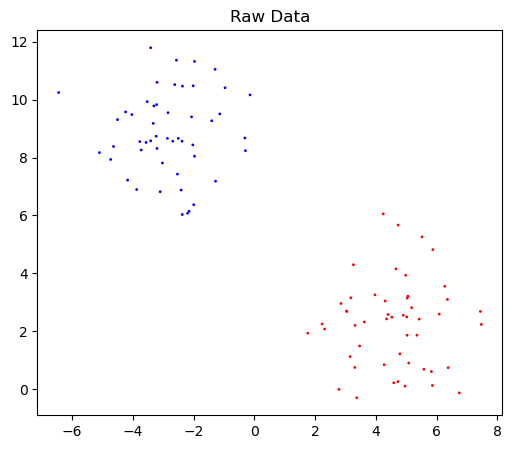

In [50]:
X, y = make_blobs(centers=2, random_state=42, cluster_std=1.5)
plt.scatter(X[:, 0], X[:, 1], c=y,s=1, cmap= 'bwr')
plt.title("Raw Data")
plt.show()


These two variables are our "features" or the columns of your data, each dot is a row of your data. The color is the label of your data. For example, you can imagine x is number of players, and y is the price of a game, so you have two groups of games, group one seem to be cheap and popular games, and group two are expensive and unpopular games. Or you can imagine any other semantics for these data points. 

## Same Data – Different Models

Notice how each model **carves space differently**.


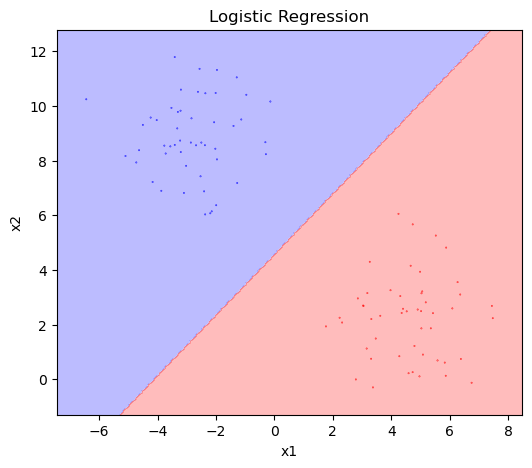

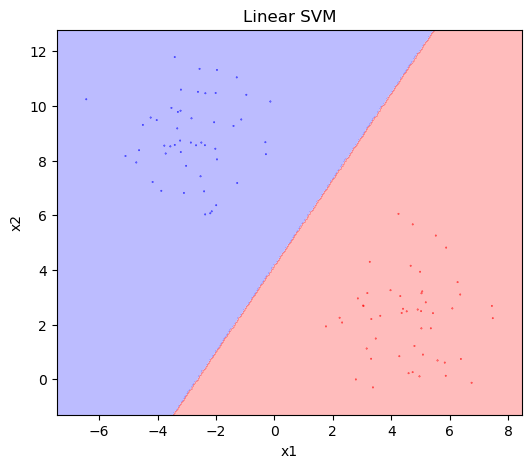

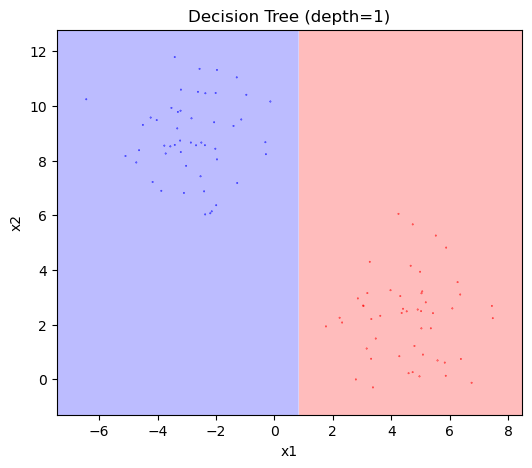

In [51]:
DT_depth= 1
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression()),
    "Linear SVM": make_pipeline(StandardScaler(), SVC(kernel="linear")),
    f"Decision Tree (depth={DT_depth})": DecisionTreeClassifier(max_depth=DT_depth)
}

for name, model in models.items():
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=name)


# Quesiton: 

These are three different algorithms, and they all ended up dividing the space by a line (even the decision tree), but a different line each time. Which line do you think is the best line and why? which one is the worst?

## 2. Nonlinear Geometry – Moons

Now we look into data that is **curved** in its original space. 

**Question**:  Change the noise level and number of data points, how do they affect the problem difficulty in your opinion?


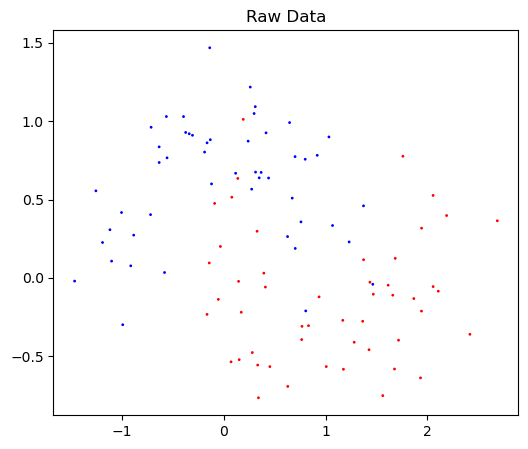

In [52]:
n_samples= 100
noise= 0.25
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)

plt.scatter(X[:, 0], X[:, 1], c=y,s=1, cmap= 'bwr')
plt.title("Raw Data")
plt.show()

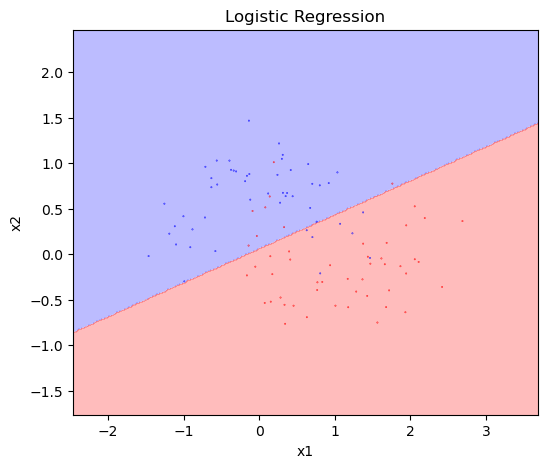

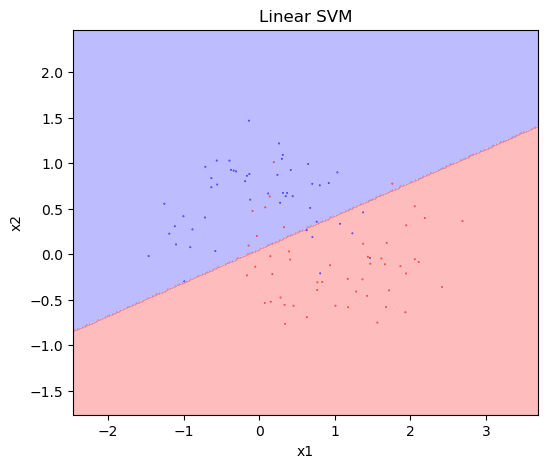

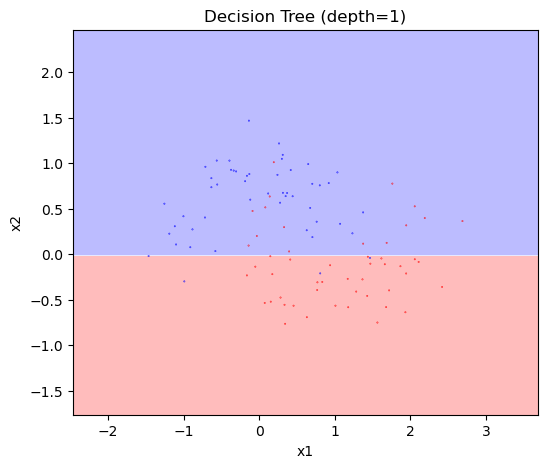

In [53]:
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)

for name, model in models.items():
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=name)


You see that the data is not separable successfully by these models. For linear SVM and logistic regression there is not much that can be done, for decision trees, you can make them more "flexible" by changing their **hyper-parameters** for example `max_depth`.

**Question**: Change the `max_depth` one by one or in a loop what do you see happening?
If you cannot get a good result, try out a simpler data generation setting (more data and less noise)

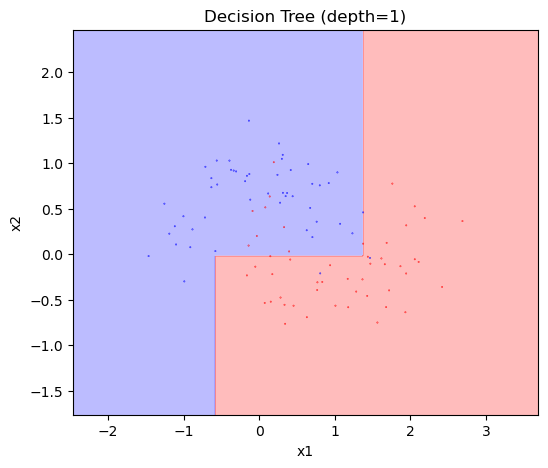

In [84]:
# we regenrate the data for ease- of experimentation
n_samples= 100
noise= 0.25
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)


DT_max_depth= 3


model =  DecisionTreeClassifier(max_depth=DT_max_depth)
model.fit(X, y)
plot_decision_boundary(model, X, y, title=name)

So we need non-linear models, and those that can use their flexibility correclty, unlike a single tree.

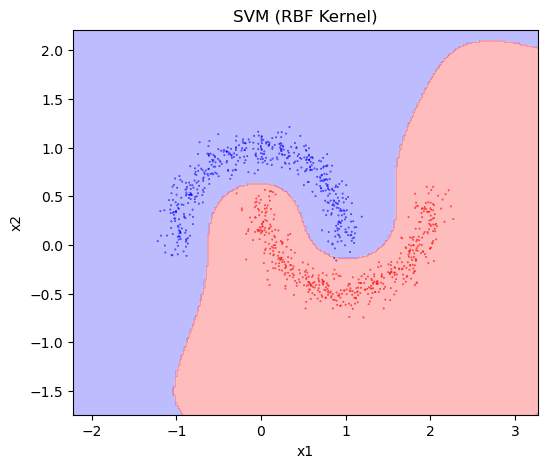

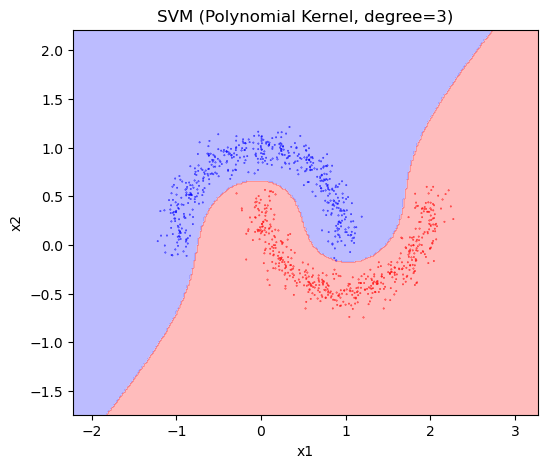

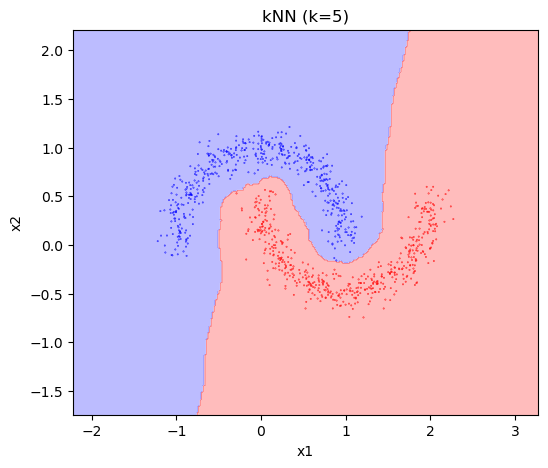

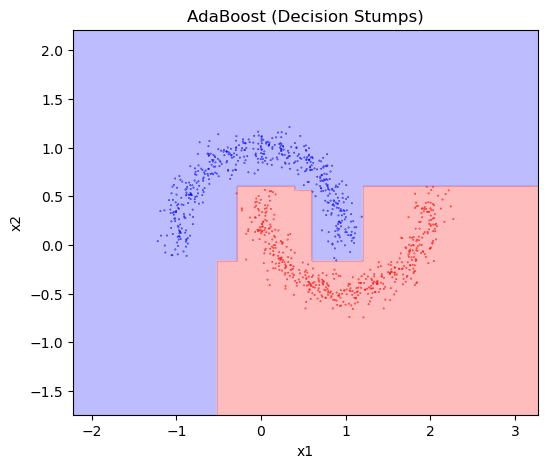

In [8]:
n_samples= 1000
noise= 0.1
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)


from sklearn.ensemble import AdaBoostClassifier

models = {
    "SVM (RBF Kernel)": make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", gamma="scale", C=1)
    ),

    "SVM (Polynomial Kernel, degree=3)": make_pipeline(
        StandardScaler(),
        SVC(kernel="poly", degree=3, coef0=1, C=1)
    ),

    "kNN (k=5)": KNeighborsClassifier(n_neighbors=5),

    "AdaBoost (Decision Stumps)": AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=2
        ),
        n_estimators=100,
        random_state=42
    )
}

for name, model in models.items():
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=name)


## 3. Controlling Complexity

Flexibility changes the boundary.

What happens if we increase model capacity?


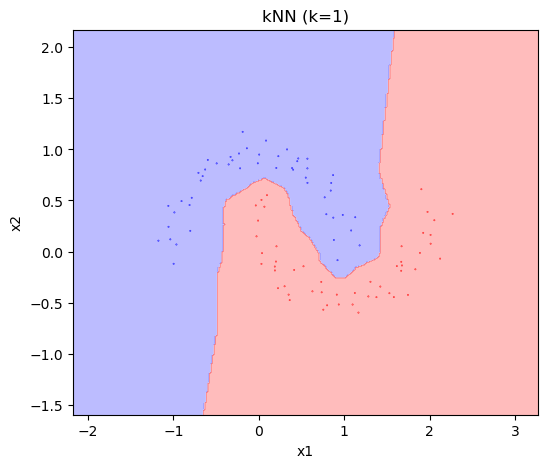

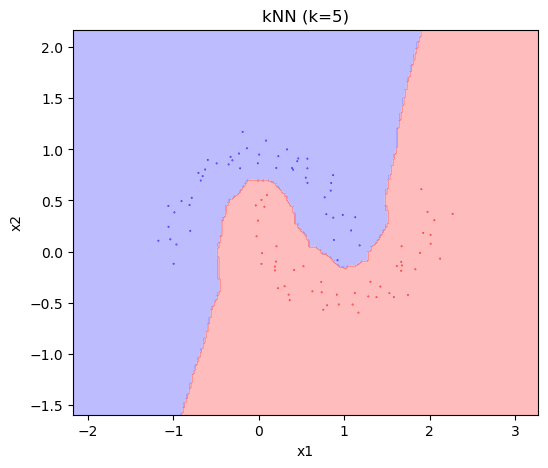

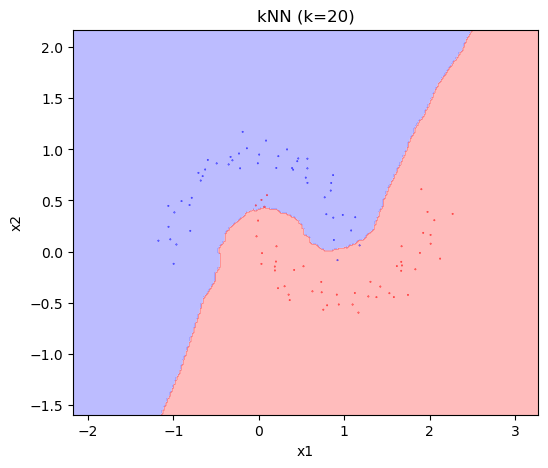

In [6]:
# kNN complexity
n_samples= 100
noise= 0.1
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)



for k in [1, 5, 20]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=f"kNN (k={k})")


**Question**: Read the definition of kNN and find explain what happens above when you change the number of neighbors. Which one makes more mistakes? Which one has more smooth boundaries? Note the errors in the KNN model with k=20, why do you think it happens?

---

Above, we saw that a single decision tree could not fit the curved data well esp with few noisy data points.
Even when we increased its depth, it either remained too simple or became unstable and started overfitting.

AdaBoost takes a different approach.

Instead of building one strong and complex model, it builds many very simple models (small trees) and combines them. Each new model focuses on the mistakes of the previous ones. Step by step, these small corrections create a strong decision boundary.

The parameter n_estimators controls how many of these small models we combine.
More estimators mean more corrections — and therefore a more flexible final model.

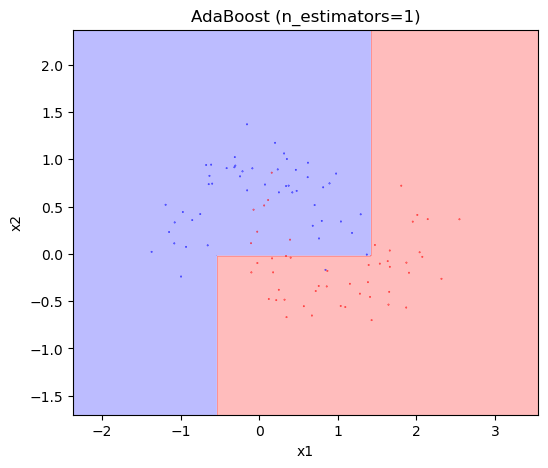

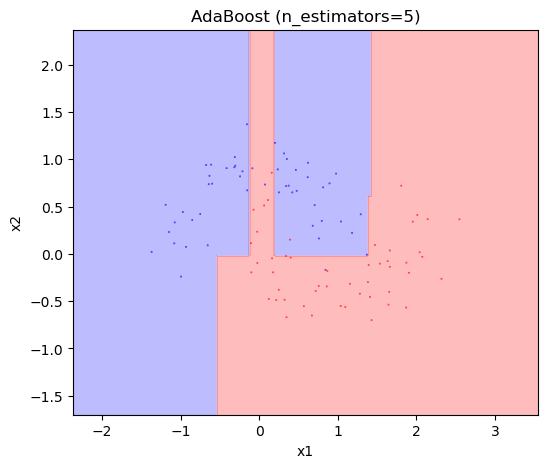

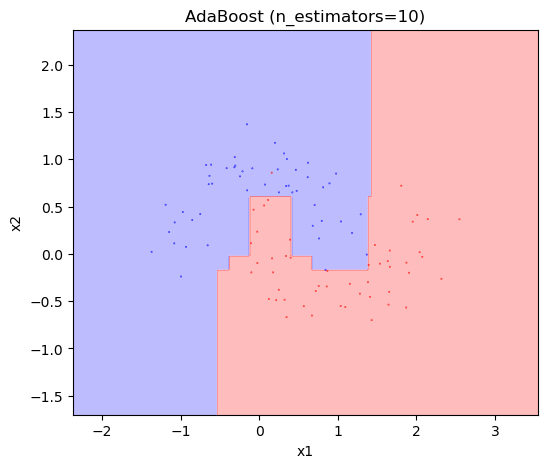

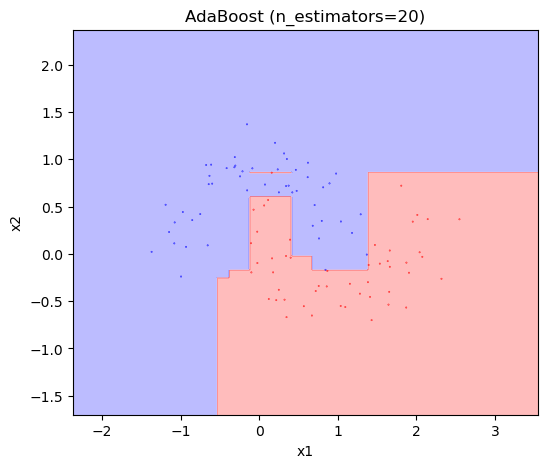

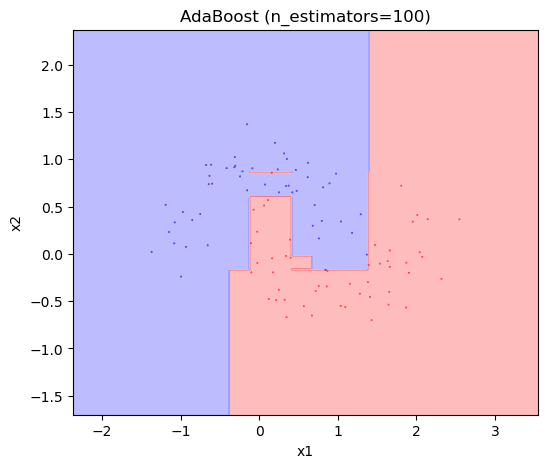

In [15]:
n_samples= 100
noise= 0.2
X, y = make_moons(noise= noise, random_state=42,n_samples=n_samples)




for n in [1, 5, 10, 20, 100]:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=2),
        n_estimators=n,
        random_state=42
    )
    model.fit(X, y)
    plot_decision_boundary(model, X, y, title=f"AdaBoost (n_estimators={n})")

Now try more data points, then try lower noise too. How does it impact the learning?